In [16]:
#Random Forest untuk Klasifikasi

#Load & Eksplorasi Data

#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, VotingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, precision_recall_curve)
from sklearn.preprocessing import LabelEncoder, StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

#Load dataset (UCI Bank Marketing Dataset)
# url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
url = "https://archive.ics.uci.edu/static/public/222/bank-additional.zip"
# Download manually atau gunakan dataset dari sklearn
from sklearn.datasets import fetch_openml

#Option 1: Gunakan fetch_openml
bank = fetch_openml(data_id=1461, as_frame=True) #bank-marketing dataset
df = bank.frame

print("Dataset Info: ")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(df.head())
print(f"\nTarget Distribution (y/Class):")
print(df['Class'].value_counts())
print(df['Class'].unique())
print(df['Class'].dtype)

#Preprocessing
#Encode categorical variables
categorical_cols = df.select_dtypes(include=['object','category']).columns
for col in categorical_cols:
    if col != 'Class':
        df[col] = LabelEncoder().fit_transform(df[col])

#Encode target
df['Class'] = (df['Class'] == '2').astype(int)

#Split features and target
X = df.drop('Class', axis=1)
y = df['Class']
print(y)

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Class distribution in Train: {y_train.value_counts().to_dict()}")

Dataset Info: 
Shape: (45211, 17)
Columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'Class']
   V1            V2       V3         V4  V5  ...  V13 V14 V15      V16  Class
0  58    management  married   tertiary  no  ...    1  -1   0  unknown      1
1  44    technician   single  secondary  no  ...    1  -1   0  unknown      1
2  33  entrepreneur  married  secondary  no  ...    1  -1   0  unknown      1
3  47   blue-collar  married    unknown  no  ...    1  -1   0  unknown      1
4  33       unknown   single    unknown  no  ...    1  -1   0  unknown      1

[5 rows x 17 columns]

Target Distribution (y/Class):
Class
1    39922
2     5289
Name: count, dtype: int64
['1', '2']
Categories (2, str): ['1', '2']
category
0        0
1        0
2        0
3        0
4        0
        ..
45206    1
45207    1
45208    1
45209    0
45210    0
Name: Class, Length: 45211, dtype: int64

Training set: (36168, 16)
Test set: (9043, 16)
Class

=== RANDOM FOREST CLASSIFIER ===
Train Accuracy: 1.0000
Test Accuracy : 0.9063
Test F1-Score : 0.5101
Test AUC-ROC  : 0.9246

Classification Report:
              precision    recall  f1-score   support

          No       0.93      0.97      0.95      7985
         Yes       0.66      0.42      0.51      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.69      0.73      9043
weighted avg       0.89      0.91      0.90      9043

cm: [[7755  230]
 [ 617  441]]


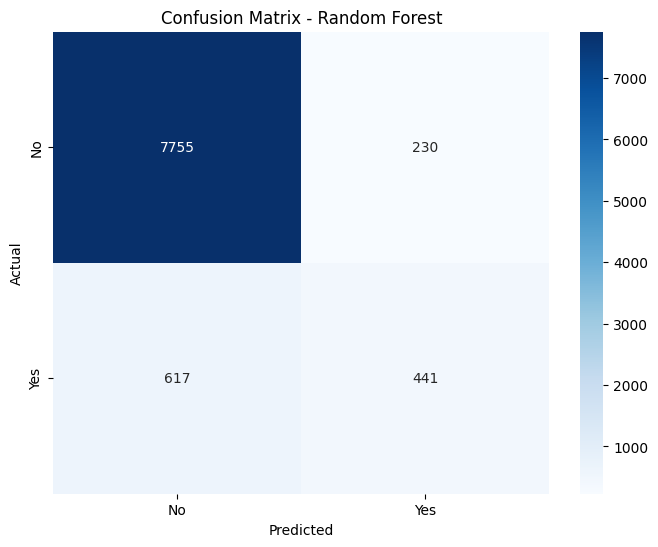

In [19]:
# Tain Random Forest Classifier

#Initialize model
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

#Train model
rf_clf.fit(X_train, y_train)

#Predictions
y_train_pred = rf_clf.predict(X_train)
y_test_pred = rf_clf.predict(X_test)
y_test_proba = rf_clf.predict_proba(X_test)[:, 1]

#Evaluation
print("=== RANDOM FOREST CLASSIFIER ===")
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Test F1-Score : {f1_score(y_test, y_test_pred):.4f}")
print(f"Test AUC-ROC  : {roc_auc_score(y_test, y_test_proba):.4f}")

#Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['No','Yes']))

#Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print(f"cm: {cm}")
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

Top 10 Feature Importance:
   feature  importance
11     V12    0.291153
5       V6    0.110084
0       V1    0.103281
9      V10    0.090262
10     V11    0.087403
15     V16    0.055356
13     V14    0.048788
1       V2    0.048493
12     V13    0.038565
3       V4    0.027879


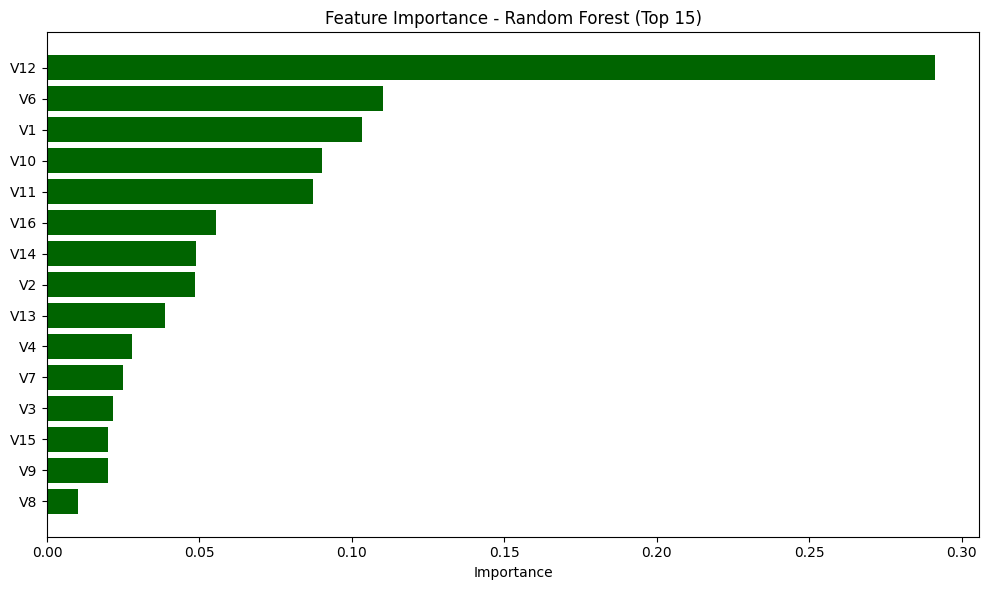


=== INSIGHT ===
Fitur paling penting: durasi kontak telepon terakhir
Interpretasi: Semakin lama nasabah diajak bicara, semakin besar minat berlangganan


In [23]:
#Feature Importance

#Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance' : rf_clf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Feature Importance:")
print(feature_importance.head(10).sort_values('importance', ascending=False))

#Visualize
plt.figure(figsize=(10,6))
plt.barh(feature_importance.head(15)['feature'],
            feature_importance.head(15)['importance'], color='darkgreen')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest (Top 15)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Insight interpretation
print("\n=== INSIGHT ===")
print("Fitur paling penting: durasi kontak telepon terakhir")
print("Interpretasi: Semakin lama nasabah diajak bicara, semakin besar minat berlangganan")

Kolom	Nama Asli
V1	age
V2	job
V3	marital
V4	education
V5	default
V6	balance
V7	housing
V8	loan
V9	contact
V10	day
V11	month
V12	duration
V13	campaign
V14	pdays
V15	previous
V16	poutcome
Class	y

In [ ]:
param_grid = {
    'n_estimators' : [50,100,200],
    'max_depth' : [10,20, None],
    'min_samples_split' : [2,5,10],
    'min_samples_leaf' : [1,2,4]
}

#Grid search with cross-validation
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print(f"Best Parameters:", grid_search.best_params_)
print("Best CV AUC-ROC: {:.4f}".format(grid_search.best_score_))

#Evaluate best model on test set
best_rf = grid_search.best_estimator_
y_test_pred_best = best_rf.predict(X_test)
y_test_proba_best = best_rf.predict_proba(X_test)[:, 1]

print(f"\nBest Model Test AUC-ROC: {roc_auc_score(y_test, y_test_proba_best):.4f}")
print(f"Improvement: {(roc_auc_score(y_test, y_test_proba_best) - roc_auc_score(y_test, y_test_proba))*100:.2f}%")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Best CV AUC-ROC: 0.9297

Best Model Test AUC-ROC: 0.9281
Improvement: -91.53%


In [25]:
print(f"Improvement: {(roc_auc_score(y_test, y_test_proba_best) - roc_auc_score(y_test, y_test_proba))*100:.2f}%")

Improvement: 0.36%


In [26]:
#Out-of-Bag (OOB) Score
rf_oob = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf_oob.fit(X_train, y_train)

print(f"OOB Score (internal validation): {rf_oob.oob_score_:.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, rf_oob.predict(X_test)):.4f}")
print("Note: OOB score adalah validasi internal tanpa perlu validation set!")

OOB Score (internal validation): 0.9031
Test Accuracy: 0.9063
Note: OOB score adalah validasi internal tanpa perlu validation set!
